# Figure 1 — LinkD-Bind benchmarking

Submitted panels a–c.

Run from top to bottom. All scientific and plotting code is contained in this notebook.

In [1]:
from pathlib import Path
from typing import Any
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyBboxPatch, PathPatch
from IPython.display import Image, Markdown, display

# Locate For_Reviewer when Jupyter starts in the repository root,
# For_Reviewer, or For_Reviewer/notebooks.
_candidates = []
for _base in (Path.cwd(), *Path.cwd().parents):
    _candidates.extend((_base, _base / "For_Reviewer"))
ROOT = next(
    (
        _path.resolve()
        for _path in _candidates
        if (_path / "notebooks").is_dir() and (_path / "README.md").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate the For_Reviewer folder.")

DATA = Path(os.environ.get("LINKD_REPRO_DATA_DIR", ROOT / "data")).resolve()
STATIC = Path(os.environ.get("LINKD_REPRO_STATIC_DIR", ROOT / "static")).resolve()
MANIFEST = DATA / "manifest.json"
RECOVERY_COMMAND = "Open notebooks/Data_Preparation.ipynb and choose Restart Kernel and Run All."
if not MANIFEST.is_file():
    raise FileNotFoundError(f"Missing {MANIFEST}. {RECOVERY_COMMAND}")

_manifest_entries = json.loads(MANIFEST.read_text(encoding="utf-8"))
_manifest_by_path = {entry["path"]: entry for entry in _manifest_entries}

def verify_input(path):
    """Verify a packaged panel table immediately before loading it."""
    relative = path.relative_to(DATA).as_posix()
    entry = _manifest_by_path.get(relative)
    if entry is None or not path.is_file():
        raise FileNotFoundError(f"Missing packaged input: {path}. {RECOVERY_COMMAND}")
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != entry["sha256"]:
        raise RuntimeError(f"Checksum mismatch for {path}. {RECOVERY_COMMAND}")

PANELS = DATA
ILLUSTRATIONS = STATIC
OUTPUT_ROOT = Path(os.environ.get("LINKD_REPRO_OUTPUT_DIR", ROOT / "outputs")).resolve()
OUTPUT_FIG = OUTPUT_ROOT / "figures"
OUTPUT_DATA = OUTPUT_ROOT / "source_data"
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "pdf.fonttype": 42, "ps.fonttype": 42, "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE = "#4C78A8"; RED = "#E45756"; TEAL = "#2A9D8F"; ORANGE = "#F4A261"; GREY = "#B8B8B8"

def panel_label(ax, value):
    ax.text(-0.15, 1.05, value, transform=ax.transAxes, fontsize=11,
            fontweight="bold", va="top")

def show_static(panel_id, title):
    """Display a submitted static panel and its bundled provenance note."""
    folder = ILLUSTRATIONS / panel_id
    process = folder / "PROCESS.md"
    if not process.is_file():
        raise FileNotFoundError(f"Missing provenance: {process}. {RECOVERY_COMMAND}")
    display(Markdown(f"### {title}\n\n" + process.read_text(encoding="utf-8")))
    assets = sorted([
        *folder.glob("*.png"), *folder.glob("*.jpg"),
        *folder.glob("*.jpeg"), *folder.glob("*.pdf"),
    ])
    if not assets:
        raise FileNotFoundError(f"Missing submitted asset in {folder}. {RECOVERY_COMMAND}")
    raster = next(
        (path for path in assets if path.suffix.lower() in {".png", ".jpg", ".jpeg"}),
        None,
    )
    if raster is not None:
        display(Image(filename=str(raster), width=720))
    else:
        display(Markdown(f"Submitted PDF asset: `{assets[0]}`"))

print("Reviewer package:", ROOT)
print("Panel data:", DATA)
print("Static assets:", STATIC)
print("Outputs:", OUTPUT_ROOT)

RANK_METHODS = ["LinkD-Bind", "FNN", "DCN", "MLP", "GraphDTA", "GCN", "Random Forest", "XGBoost", "DeepPurpose", "DeepDTA", "GBM", "SVR", "Linear Regression"]
RANK_SPLITS = ["Random", "Cold-protein", "Cold-drug"]
FIG1C_MODEL_MAP = {"LinkD": "LinkD-Bind", "Diffusion": "Diffusion backbone only", "FNN": "Head only (no diffusion)", "GraphDTA": "GraphDTA", "DeepPurpose": "DeepPurpose", "DeepDTA": "DeepDTA"}

Reviewer package: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer
Panel data: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/data
Static assets: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/static
Outputs: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs


## Panel 1a — published LinkD framework

Static published schematic with provenance.

### Panel 1a — published LinkD framework

### Process (schematic — not regenerated from data)

LinkD integrates four modules:

1. **LinkD-Bind** — ChemBERTa (SMILES) + ESM2 (protein) → shared latent space → diffusion refinement → hybrid MLP/RF head predicting proteome-wide pKd.
2. **LinkD-Select** — entropy / gap / selectivity-ratio metrics → composite selectivity score.
3. **LinkD-Pheno** — drug-sensitivity × CRISPR dependency concordance across cancer cell lines; EHR odds/hazard ratios in Mount Sinai + UK Biobank.
4. **LinkD-Agent** — natural-language queries decomposed into auditable analytical steps.

The published composite panel below is the manuscript figure (Illustrator/Photoshop assembly).


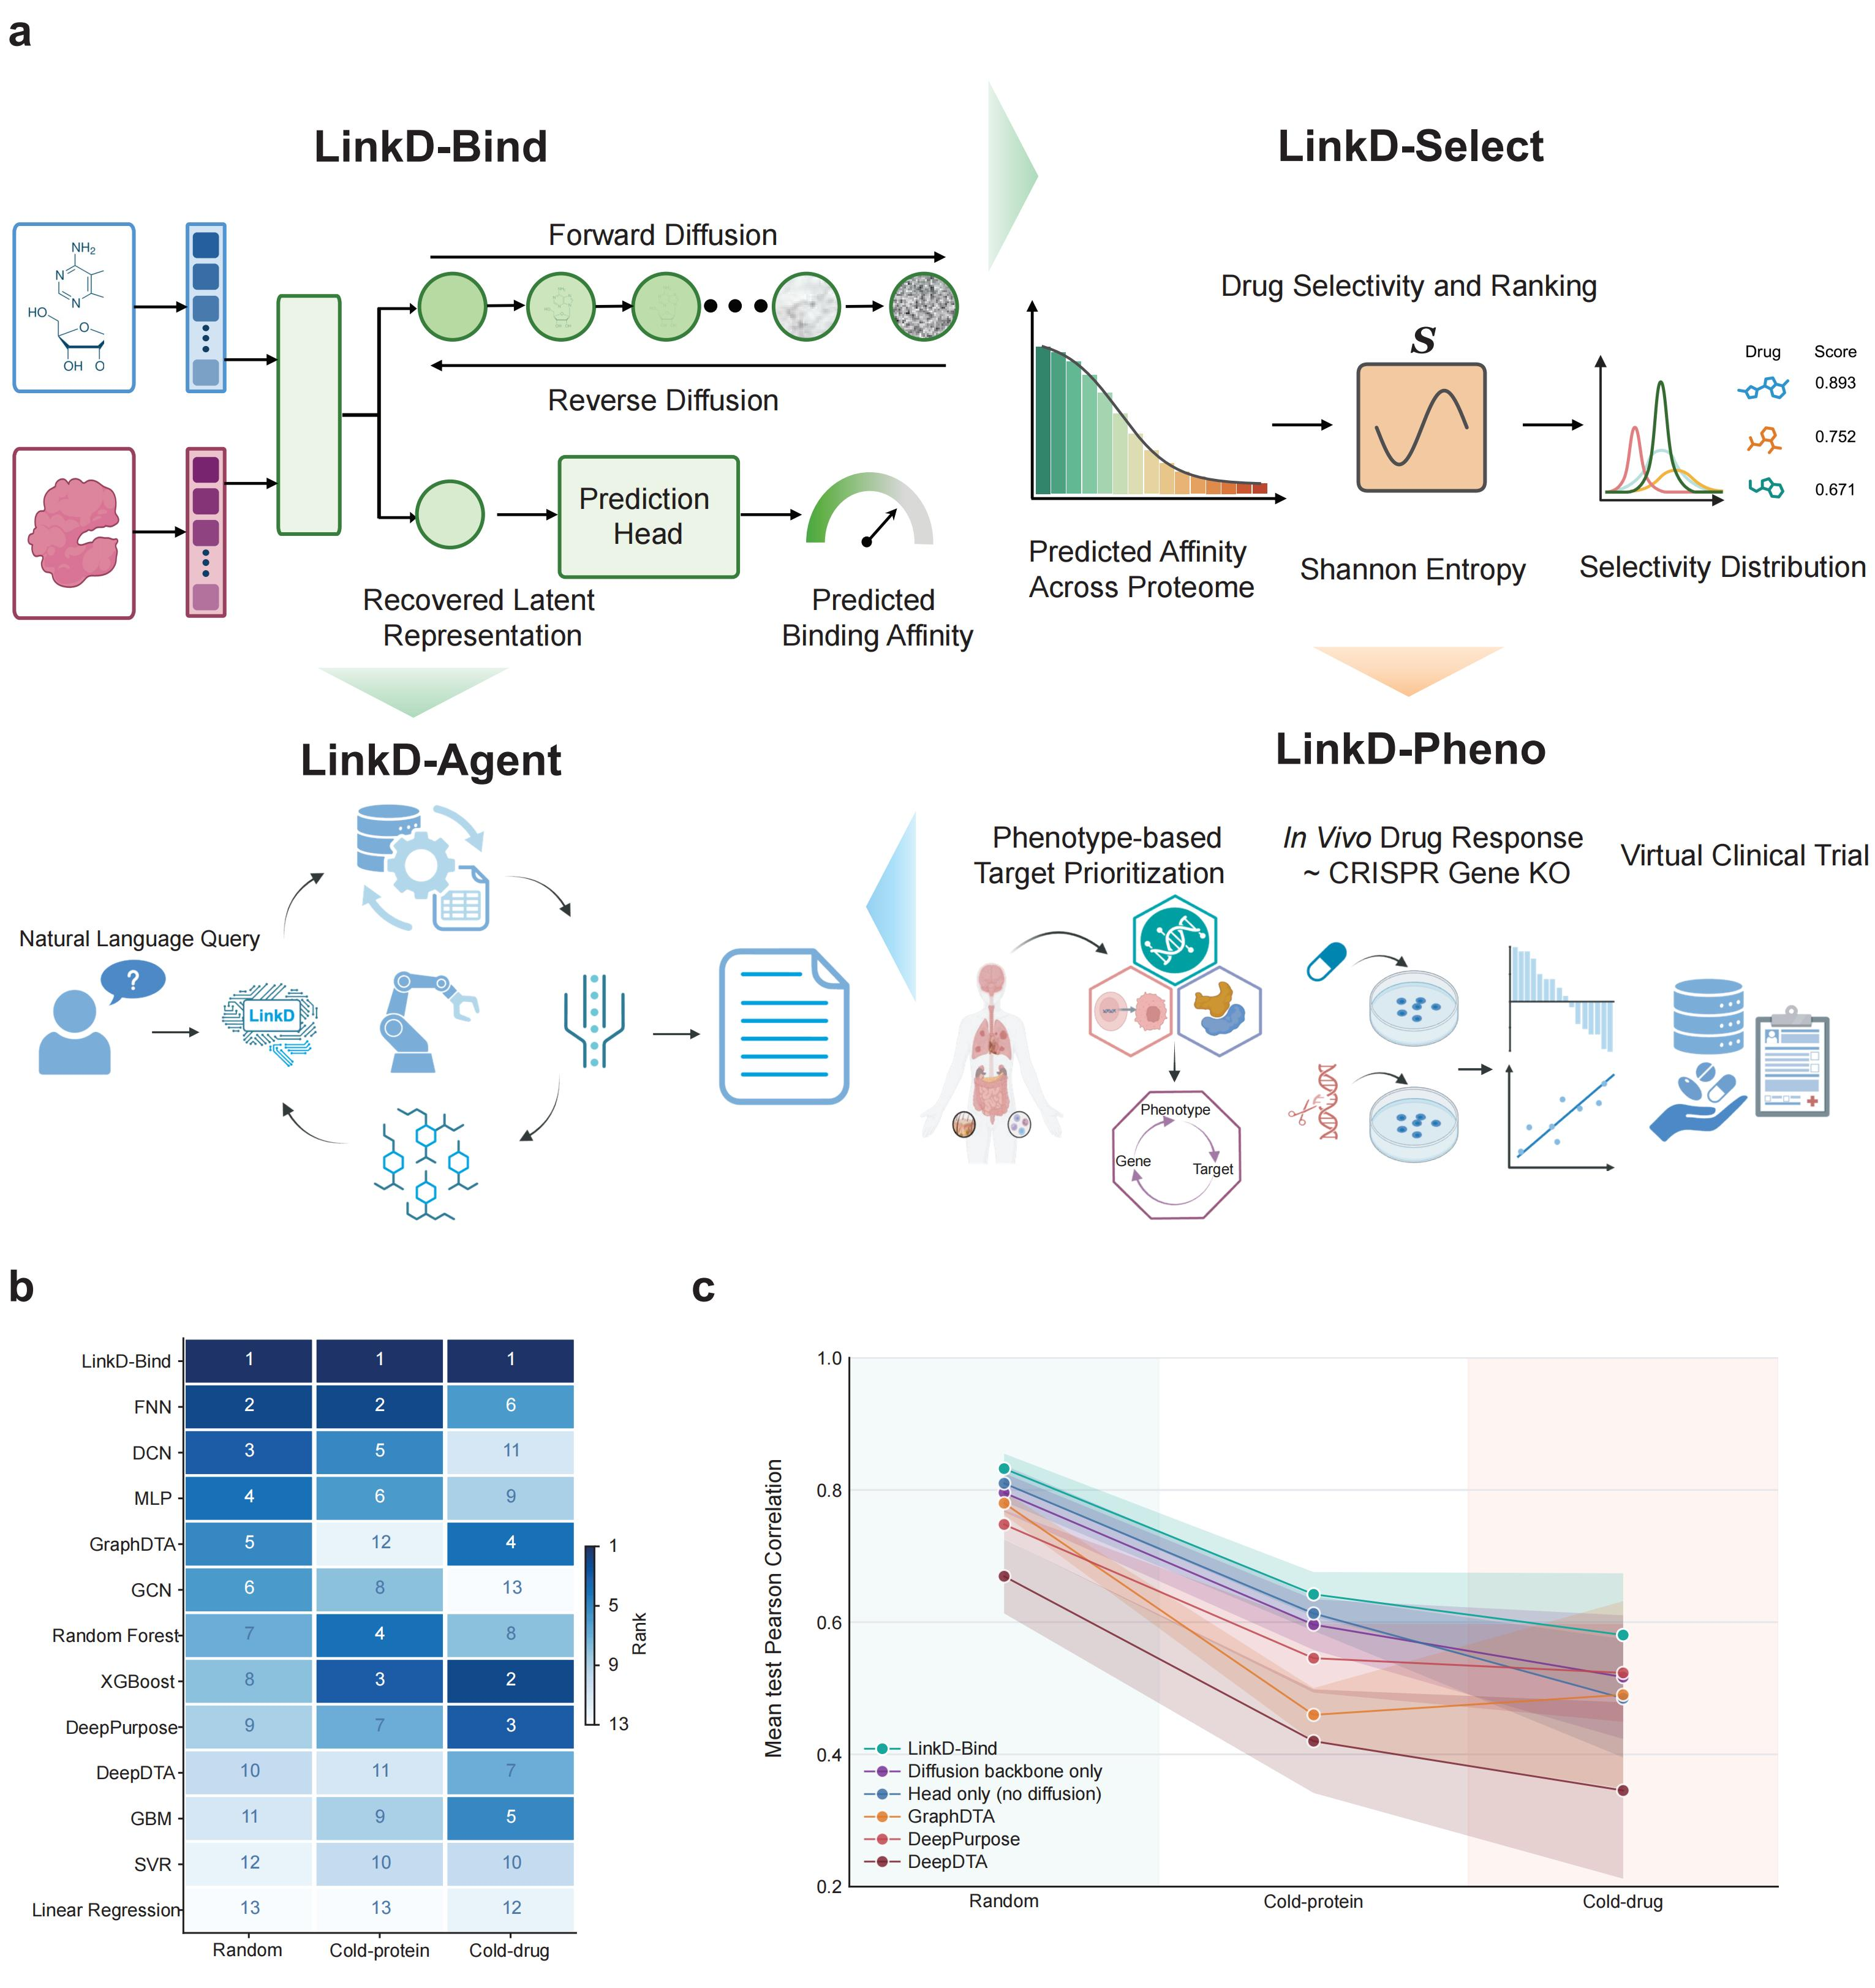

In [2]:
show_static("fig1_a", "Panel 1a — published LinkD framework")

## fig1 b — Benchmark rank heatmap

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [3]:
verify_input(PANELS / "fig1b.csv")
data = pd.read_csv(PANELS / "fig1b.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (39, 3)
columns: ['method', 'split', 'rank']


,method,split,rank
0,LinkD-Bind,Random,1
1,LinkD-Bind,Cold-protein,1
2,LinkD-Bind,Cold-drug,1
3,FNN,Random,2
4,FNN,Cold-protein,2


In [4]:
assert data["method"].nunique() == 13
assert set(data["split"]) == set(RANK_SPLITS)
assert (data.loc[data["method"] == "LinkD-Bind", "rank"] == 1).all()
print("PASS — fig1_b manuscript invariants")

PASS — fig1_b manuscript invariants


In [5]:
prepared = data.pivot(index="method", columns="split", values="rank").reindex(index=RANK_METHODS, columns=RANK_SPLITS)
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (13, 3)


split,Random,Cold-protein,Cold-drug
method,,,
LinkD-Bind,1,1,1
FNN,2,2,6
DCN,3,5,11
MLP,4,6,9
GraphDTA,5,12,4


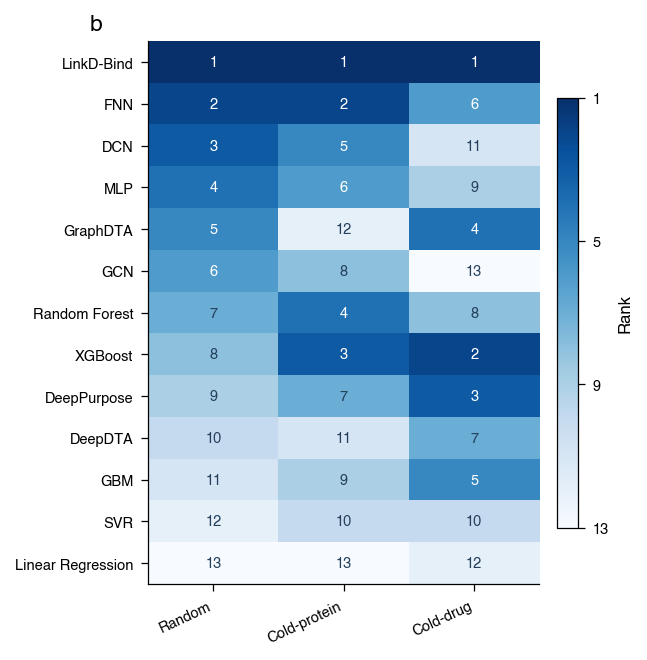

In [6]:
def plot_fig1b(matrix: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(3.7, 4.7))
    image = ax.imshow(-matrix.values, cmap="Blues", aspect="auto", vmin=-13, vmax=-1)
    ax.set_xticks(range(3), matrix.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(matrix)), matrix.index)
    for y in range(len(matrix)):
        for x in range(3):
            rank = int(matrix.iloc[y, x])
            ax.text(x, y, str(rank), ha="center", va="center", fontsize=7,
                    color="white" if rank <= 6 else "#24405c")
    cbar = fig.colorbar(image, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_ticks([-13, -9, -5, -1]); cbar.set_ticklabels(["13", "9", "5", "1"])
    cbar.set_label("Rank"); panel_label(ax, "b")
    return fig, matrix.reset_index()


figure, plotted_source = plot_fig1b(prepared)
display(figure)
plt.close(figure)

In [7]:
pdf_path = OUTPUT_FIG / "fig1_b_rank_heatmap.pdf"
png_path = OUTPUT_FIG / "fig1_b_rank_heatmap.png"
csv_path = OUTPUT_DATA / "fig1_b_rank_heatmap.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig1_b_rank_heatmap", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: 13 methods; LinkD-Bind ranks first.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig1_b_rank_heatmap.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig1_b_rank_heatmap.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig1_b_rank_heatmap.csv
Panel result: 13 methods; LinkD-Bind ranks first.


## fig1 c — Six-method performance curves

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [8]:
verify_input(PANELS / "fig1c.csv")
data = pd.read_csv(PANELS / "fig1c.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (18, 5)
columns: ['model', 'split', 'mean', 'sd', 'n']


,model,split,mean,sd,n
0,DeepDTA,Cold-drug,0.345373,0.231037,3
1,DeepDTA,Cold-protein,0.420006,0.135709,2
2,DeepDTA,Random,0.669465,0.097259,3
3,DeepPurpose,Cold-drug,0.523271,0.128035,3
4,DeepPurpose,Cold-protein,0.545524,0.090259,3


In [9]:
assert set(data["split"]) == set(RANK_SPLITS)
assert set(data["model"]) == set(FIG1C_MODEL_MAP.values())
assert data[["mean", "sd"]].notna().all().all()
print("PASS — fig1_c manuscript invariants")

PASS — fig1_c manuscript invariants


In [10]:
prepared = data.copy()
prepared["split"] = pd.Categorical(prepared["split"], RANK_SPLITS, ordered=True)
prepared = prepared.sort_values(["model", "split"])
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (18, 5)


,model,split,mean,sd,n
2,DeepDTA,Random,0.669465,0.097259,3
1,DeepDTA,Cold-protein,0.420006,0.135709,2
0,DeepDTA,Cold-drug,0.345373,0.231037,3
5,DeepPurpose,Random,0.747832,0.037592,3
4,DeepPurpose,Cold-protein,0.545524,0.090259,3


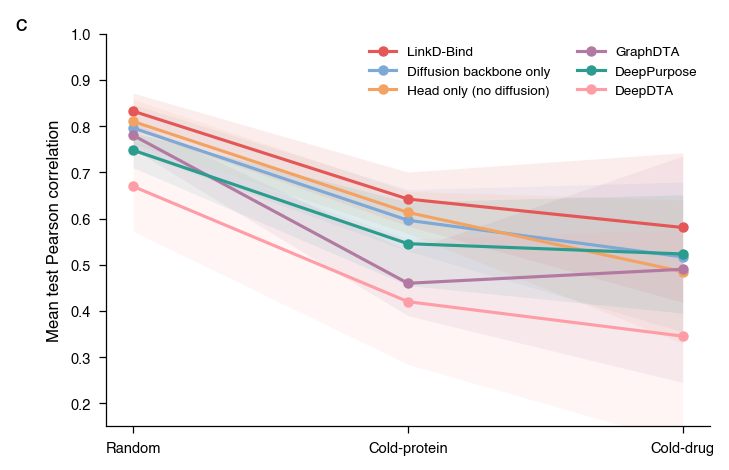

In [11]:
def plot_fig1c(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    models = list(FIG1C_MODEL_MAP.values())
    colors = [RED, "#7EA8D6", ORANGE, "#B279A2", TEAL, "#FF9DA6"]
    fig, ax = plt.subplots(figsize=(5.2, 3.4)); x = np.arange(3)
    for model, color in zip(models, colors):
        sub = data[data["model"] == model].set_index("split").reindex(RANK_SPLITS)
        ax.plot(x, sub["mean"], marker="o", lw=1.5, ms=4, label=model, color=color)
        ax.fill_between(x, (sub["mean"] - sub["sd"].fillna(0)).to_numpy(float),
                        (sub["mean"] + sub["sd"].fillna(0)).to_numpy(float),
                        color=color, alpha=0.10, linewidth=0)
    ax.set_xticks(x, RANK_SPLITS); ax.set_ylim(0.15, 1)
    ax.set_ylabel("Mean test Pearson correlation")
    ax.legend(frameon=False, fontsize=6.5, ncol=2); panel_label(ax, "c")
    return fig, data


figure, plotted_source = plot_fig1c(prepared)
display(figure)
plt.close(figure)

In [12]:
pdf_path = OUTPUT_FIG / "fig1_c_performance.pdf"
png_path = OUTPUT_FIG / "fig1_c_performance.png"
csv_path = OUTPUT_DATA / "fig1_c_performance.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig1_c_performance", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Means and confidence bands across three evaluation modes.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig1_c_performance.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig1_c_performance.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig1_c_performance.csv
Panel result: Means and confidence bands across three evaluation modes.


## Complete

All assigned panels were displayed inline and exported as PDF, PNG, and source CSV where computational.